###I structured the notebook in 3 parts:
###Part A data cleaning (Datetype inconsistencies ,understanding structure , identifying missing values wherever needed),
###Part B constructing first attribution, joins, aggregations and economics tables for profit calculation,
###Part C answering business questions using derived tables above with some transormations.

#Part A

In [1]:
import pandas as pd
import numpy as np

In [2]:
vehicles = pd.read_csv('/content/vehicles.csv')
ad_channels = pd.read_csv('/content/ad_channels.csv')
clicks = pd.read_csv('/content/clicks.csv')
locks  =pd.read_csv('/content/locks.csv')
sales = pd.read_csv('/content/sales.csv')
spend = pd.read_csv('/content/spend.csv')

#Renaming the channel colummn to channel in ad_channels,parsing channel name from ad_channels data set

In [3]:
ad_channels.head()

,channel_id,channel
0,1,Search Engine-Hooli_Convertible
1,2,Search Engine-Hooli_Sedan
2,3,Search Engine-Hooli_Truck
3,4,Search Engine-Bam_Convertible
4,5,Search Engine-Bam_Sedan


In [4]:
ad_channels = ad_channels.rename(columns={"channel": "channel_name"})

###Parsing Category

In [5]:
tmp = ad_channels["channel_name"].str.split("-", n=1, expand=True)
ad_channels["category"] = tmp[0].str.strip() #defining category
rest = tmp[1].str.strip()

###Parsing Partner

In [6]:
tmp2 = rest.str.split("_", n=1, expand=True)
ad_channels["partner"] = tmp2[0].str.strip() #defining channels

###Parsing Campaign

In [7]:
ad_channels["campaign"] = tmp2[1].fillna(ad_channels["partner"]).str.strip() #defining campaign

###Post Transformation

In [8]:
ad_channels.head(15)
#for channels without a campaign, partner becomes the campaign

,channel_id,channel_name,category,partner,campaign
0,1,Search Engine-Hooli_Convertible,Search Engine,Hooli,Convertible
1,2,Search Engine-Hooli_Sedan,Search Engine,Hooli,Sedan
2,3,Search Engine-Hooli_Truck,Search Engine,Hooli,Truck
3,4,Search Engine-Bam_Convertible,Search Engine,Bam,Convertible
4,5,Search Engine-Bam_Sedan,Search Engine,Bam,Sedan
5,6,Search Engine-Bam_Truck,Search Engine,Bam,Truck
6,7,Online Video-Datankle_Teen,Online Video,Datankle,Teen
7,8,Online Video-Datankle_25+,Online Video,Datankle,25+
8,9,Online Video-WeTube_Teen,Online Video,WeTube,Teen
9,10,Online Video-WeTube_25+,Online Video,WeTube,25+


In [9]:
ad_channels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   channel_id    16 non-null     int64 
 1   channel_name  16 non-null     object
 2   category      16 non-null     object
 3   partner       16 non-null     object
 4   campaign      16 non-null     object
dtypes: int64(1), object(4)
memory usage: 772.0+ bytes


#Data Hygiene check to find missing values, Incorrect data types

In [10]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   make        40 non-null     object 
 1   model       40 non-null     object 
 2   bodystyle   40 non-null     object 
 3   avg_margin  40 non-null     float64
dtypes: float64(1), object(3)
memory usage: 1.4+ KB


In [11]:
vehicles.isna().sum()

,0
make,0
model,0
bodystyle,0
avg_margin,0


In [12]:
ad_channels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   channel_id    16 non-null     int64 
 1   channel_name  16 non-null     object
 2   category      16 non-null     object
 3   partner       16 non-null     object
 4   campaign      16 non-null     object
dtypes: int64(1), object(4)
memory usage: 772.0+ bytes


In [13]:
ad_channels.isna().sum()


,0
channel_id,0
channel_name,0
category,0
partner,0
campaign,0


In [14]:
clicks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168907 entries, 0 to 168906
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   click_datetime  168907 non-null  object
 1   channel_id      168907 non-null  int64 
 2   user_id         168907 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.9+ MB


In [15]:
clicks["click_datetime"].astype(str).str.len().value_counts().sort_index()


,count
click_datetime,
26,135574
29,33333


###converting datetime into date time format

In [16]:
clicks["click_datetime"] = pd.to_datetime(clicks["click_datetime"])

In [17]:
clicks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168907 entries, 0 to 168906
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   click_datetime  168907 non-null  datetime64[ns]
 1   channel_id      168907 non-null  int64         
 2   user_id         168907 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 3.9 MB


In [18]:
clicks.head()

,click_datetime,channel_id,user_id
0,2022-08-16 22:40:45.354986,9,18878402
1,2022-08-12 09:44:06.717217,3,37693359
2,2022-11-20 07:44:40.178093,15,95101706
3,2022-11-08 20:29:41.890408,14,90468324
4,2022-07-17 19:50:32.656824,8,73921344


In [19]:
clicks.isna().sum()

,0
click_datetime,0
channel_id,0
user_id,0


In [20]:
locks.head()

,lock_id,user_id,lock_datetime
0,1,25624288,2022-10-02 18:15:22.934654
1,2,30724645,2022-12-10 17:25:19.501565
2,3,1063348,2022-11-28 21:32:46.776564
3,4,60837031,2022-09-16 23:19:00.526480
4,5,91321232,2022-11-17 07:28:13.848280


In [21]:
locks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13991 entries, 0 to 13990
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   lock_id        13991 non-null  int64 
 1   user_id        13991 non-null  int64 
 2   lock_datetime  13991 non-null  object
dtypes: int64(2), object(1)
memory usage: 328.0+ KB


In [22]:
locks["lock_datetime"].astype(str).str.len().value_counts().sort_index()

,count
lock_datetime,
13,108
14,1120
15,2866
16,1911
26,7986


In [23]:
locks["lock_datetime"] = pd.to_datetime(locks["lock_datetime"], format = "mixed")

In [24]:
locks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13991 entries, 0 to 13990
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   lock_id        13991 non-null  int64         
 1   user_id        13991 non-null  int64         
 2   lock_datetime  13991 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2)
memory usage: 328.0 KB


In [25]:
locks.isna().sum()

,0
lock_id,0
user_id,0
lock_datetime,0


In [26]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            1335 non-null   float64
 1   lock_id            1348 non-null   int64  
 2   sale_datetime      1348 non-null   object 
 3   sale_id            1348 non-null   int64  
 4   make               1348 non-null   object 
 5   model              1348 non-null   object 
 6   has_trade_in       1348 non-null   int64  
 7   is_financed        1348 non-null   int64  
 8   apr                417 non-null    float64
 9   delivery_distance  1348 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 105.4+ KB


In [27]:
sales["sale_datetime"] = pd.to_datetime(
    sales["sale_datetime"],
)


In [28]:
sales.isna().sum()

,0
user_id,13
lock_id,0
sale_datetime,0
sale_id,0
make,0
model,0
has_trade_in,0
is_financed,0
apr,931
delivery_distance,0


In [29]:
missing_users = sales[sales["user_id"].isna()]

In [30]:
check = missing_users.merge(
    locks[["lock_id", "user_id"]],
    on="lock_id",
    how="left",
    indicator=True
)

In [31]:
check.head(2)

,user_id_x,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance,user_id_y,_merge
0,NaN,25147781,2022-10-06 18:53:00,1603253,Honda,HR-V,0,0,NaN,493,29118032,both
1,NaN,25216987,2022-09-22 16:37:00,1592535,Land Rover,Range Rover,0,0,NaN,0,29180298,both


In [32]:
check["_merge"].value_counts()

,count
_merge,
both,13
left_only,0
right_only,0


###All 13 sales rows with missing user_id, have a matching lock_id in the locks table for us to retrive their respective user_id

In [33]:
recovered = (check["_merge"] == "both").sum()

In [34]:
sales = sales.merge(
    locks[["lock_id", "user_id"]].rename(columns={"user_id": "lock_user_id"}),
    on="lock_id",
    how="left"
)

sales["user_id"] = sales["user_id"].fillna(sales["lock_user_id"])
sales = sales.drop(columns=["lock_user_id"])

In [35]:
sales.isna().sum()

,0
user_id,0
lock_id,0
sale_datetime,0
sale_id,0
make,0
model,0
has_trade_in,0
is_financed,0
apr,931
delivery_distance,0


#Now converting user_id to int64

In [36]:
sales["user_id"] = sales["user_id"].astype("int64")


In [37]:
spend.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3424 entries, 0 to 3423
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   channel_id  3424 non-null   int64  
 1   date        3424 non-null   object 
 2   spend       3424 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 80.4+ KB


In [38]:
spend["date"] = pd.to_datetime(spend["date"])

In [39]:
spend.isna().sum()

,0
channel_id,0
date,0
spend,0


#Part B construction of first attribution and economics tables like spend, sales numbers, Gross profit

###Channel wise performance table
###Attaching category / partner / campaign to spend

###Enriching the spend table with the channel meta data for further analysis

In [40]:
new_spend = spend.merge(
    ad_channels[["channel_id", "category", "partner", "campaign"]],
    on="channel_id",
    how="left"
)

In [41]:
new_spend.head()

,channel_id,date,spend,category,partner,campaign
0,1,2022-06-01,134.07,Search Engine,Hooli,Convertible
1,1,2022-06-02,45.11,Search Engine,Hooli,Convertible
2,1,2022-06-03,66.23,Search Engine,Hooli,Convertible
3,1,2022-06-04,28.03,Search Engine,Hooli,Convertible
4,1,2022-06-05,33.95,Search Engine,Hooli,Convertible


#Aggregating Spend by channel

In [42]:
spend_by_channel = (
    new_spend
    .groupby("channel_id", as_index=False)["spend"]
    .sum()
    .rename(columns={"spend": "total_spend"})
)
spend_by_channel.head()

,channel_id,total_spend
0,1,24999.95
1,2,29999.95
2,3,25000.15
3,4,11999.94
4,5,14999.98


In [43]:
new_spend_table = (
    new_spend
    .groupby("channel_id", as_index=False)
    .agg(
        total_spend=("spend", "sum"),
        category=("category", "first"),
        partner=("partner", "first"),
        campaign=("campaign", "first")
    )
)
new_spend_table.head()

,channel_id,total_spend,category,partner,campaign
0,1,24999.95,Search Engine,Hooli,Convertible
1,2,29999.95,Search Engine,Hooli,Sedan
2,3,25000.15,Search Engine,Hooli,Truck
3,4,11999.94,Search Engine,Bam,Convertible
4,5,14999.98,Search Engine,Bam,Sedan


#Checking the scope of dates

In [44]:
clicks["click_datetime"].min(), clicks["click_datetime"].max()


(Timestamp('2022-05-18 07:36:52'), Timestamp('2023-04-02 10:29:22.048210260'))

###clicks table only contains clicks in 2022 which means apples to apples comparision
###we are comparing 2022 spend vs 2022 clicks


In [45]:
clicks_by_channel = (
    clicks
    .groupby("channel_id", as_index=False)
    .size()
    .rename(columns={"size": "total_clicks"})
)

clicks_by_channel.shape


(16, 2)

In [46]:
clicks_by_channel.head()

,channel_id,total_clicks
0,1,20977
1,2,29324
2,3,15392
3,4,6835
4,5,12182


###Merging clicks to new_spend_table

In [47]:
channel_performance = spend_by_channel.merge(
    clicks_by_channel,
    on="channel_id",
    how="left"
)
channel_performance.head(16)

,channel_id,total_spend,total_clicks
0,1,24999.95,20977
1,2,29999.95,29324
2,3,25000.15,15392
3,4,11999.94,6835
4,5,14999.98,12182
5,6,12000.12,9881
6,7,5000.04,2505
7,8,14999.98,7265
8,9,5000.00,2370
9,10,14500.04,6343


#Calculating CPC

In [48]:
channel_performance["cpc"] = np.where(
    channel_performance["total_clicks"] > 0,
    channel_performance["total_spend"] / channel_performance["total_clicks"],
    np.nan
)
channel_performance.head(16)

,channel_id,total_spend,total_clicks,cpc
0,1,24999.95,20977,1.191779
1,2,29999.95,29324,1.023051
2,3,25000.15,15392,1.624230
3,4,11999.94,6835,1.755661
4,5,14999.98,12182,1.231323
5,6,12000.12,9881,1.214464
6,7,5000.04,2505,1.996024
7,8,14999.98,7265,2.064691
8,9,5000.00,2370,2.109705
9,10,14500.04,6343,2.285991


#Checking the scope for sales entries in sales table

In [49]:
sales["sale_datetime"].min(), sales["sale_datetime"].max()


(Timestamp('2022-09-09 21:48:00'), Timestamp('2023-04-23 19:40:00'))

###confining the scope of the study to 2022

In [50]:
sales_2022 = sales[
    (sales["sale_datetime"] >= "2022-01-01") &
    (sales["sale_datetime"] <  "2023-01-01")
]

###sorting clicks as per the date_time for every user

In [51]:
clicks_sorted = clicks.sort_values(
    by=["user_id", "click_datetime"]
)

#Defining first_attribution

In [52]:
first_attribution = (
    clicks_sorted
    .groupby("user_id", as_index=False)
    .first()[["user_id", "click_datetime", "channel_id"]]
    .rename(columns={
        "click_datetime": "first_click_datetime"
    })
)

In [53]:
first_attribution.head()

,user_id,first_click_datetime,channel_id
0,10833,2022-06-21 22:17:39.543875,4
1,13887,2022-07-15 07:59:13.644703,13
2,13963,2022-07-07 19:22:56.553279,15
3,14696,2022-10-30 14:52:08.135901,2
4,15249,2022-08-17 03:17:05.901867,13


###adding campaign meta data to the first_attribution

In [54]:
first_attribution = first_attribution.merge(
    ad_channels[["channel_id", "category", "partner", "campaign"]],
    on="channel_id",
    how="left"
)

In [55]:
first_attribution.head(10)

,user_id,first_click_datetime,channel_id,category,partner,campaign
0,10833,2022-06-21 22:17:39.543875,4,Search Engine,Bam,Convertible
1,13887,2022-07-15 07:59:13.644703,13,Social Media,KnickKnack,KnickKnack
2,13963,2022-07-07 19:22:56.553279,15,Third Party Listing,RealTruck,RealTruck
3,14696,2022-10-30 14:52:08.135901,2,Search Engine,Hooli,Sedan
4,15249,2022-08-17 03:17:05.901867,13,Social Media,KnickKnack,KnickKnack
5,15957,2022-10-29 20:54:00.788410,2,Search Engine,Hooli,Sedan
6,19093,2022-11-13 22:44:54.228763,2,Search Engine,Hooli,Sedan
7,19327,2022-09-30 10:25:34.565024,3,Search Engine,Hooli,Truck
8,19848,2022-08-18 23:17:05.800788,11,Finance Partnership,Debit Dharma,Debit Dharma
9,21272,2022-08-15 09:17:50.716643,16,Third Party Listing,ManualBarter,ManualBarter


###Total Spend by Partner

In [56]:
spend_by_partner = (
    new_spend
    .groupby("partner", as_index=False)["spend"]
    .sum()
    .rename(columns={"spend": "total_spend"})
)
spend_by_partner.head()


,partner,total_spend
0,Bam,39000.04
1,Datankle,20000.02
2,Debit Dharma,19999.99
3,Giving Vine,18500.05
4,HeadLedger,19999.95


In [57]:
sales_attr = sales.merge(
    first_attribution[["user_id", "partner"]],
    on="user_id",
    how="left"
)
sales_attr.head()

,user_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance,partner
0,27416583,23163572,2022-09-14 20:13:00,1591322,Honda,Civic,1,0,NaN,719,Datankle
1,11528490,24043656,2022-09-27 21:28:00,1592709,Toyota,Tacoma,0,1,0.131,388,Debit Dharma
2,28075930,24380774,2022-09-20 20:14:00,1592345,Jeep,Wrangler,0,0,NaN,350,Debit Dharma
3,28563986,24486868,2022-09-15 19:31:00,1592059,Mercedes-Benz,GLC,0,0,NaN,1057,Hooli
4,28591774,24520951,2022-09-11 21:53:00,1591860,Mercedes-Benz,GLC,1,0,NaN,184,NaN


###missing first click partner attribution

In [58]:
sales_attr["partner"].isna().sum()


np.int64(27)

#Part C

#ANSWERS

#Performance & Economics

#Q1.What category of channel has the lowest cost per click Why do you think this channel has the lowest CPC?

In [59]:
channel_performance_sorted = (
    channel_performance
    .dropna(subset=["cpc"])
    .sort_values("cpc", ascending=True)
)

Lowest_CPC_channel_id = channel_performance_sorted.iloc[0]
print(Lowest_CPC_channel_id)
channel_performance_sorted.head()

channel_id          2.000000
total_spend     29999.950000
total_clicks    29324.000000
cpc                 1.023051
Name: 1, dtype: float64


,channel_id,total_spend,total_clicks,cpc
1,2,29999.95,29324,1.023051
0,1,24999.95,20977,1.191779
5,6,12000.12,9881,1.214464
4,5,14999.98,12182,1.231323
13,14,19999.95,15534,1.287495


In [60]:
lowest_channel_id = int(Lowest_CPC_channel_id["channel_id"])

lowest_channel_row = (
    ad_channels.loc[ad_channels["channel_id"] == lowest_channel_id, "channel_name"]
    .iloc[0]
)

category = lowest_channel_row.split("-", 1)[0]   # everything before first "-"
print("Lowest CPC channel_id:", lowest_channel_id)
print("channel_name:", lowest_channel_row)
print("category:", category)


Lowest CPC channel_id: 2
channel_name: Search Engine-Hooli_Sedan
category: Search Engine


###Interpretation: Hooli sedan focused search campaigns are delivering the least Cost per click at 1.02 per click, also it highlights search as an efficient cateogory for this partner interms of cpc.

#Q2.What are the top three campaigns in terms of number of sales generated by first touch attribution?

###Assumption: Although the question asks for campaign level performance by first attribution, multiple partners are running same campaigns, for example sedan campaign by both hooli and bam. To avoid inflating results, i calculated at a category_Partner-campaign level

In [61]:
ad_channels["campaign_key"] = ad_channels["category"] + " - " +  ad_channels["partner"] + "_" +  ad_channels["campaign"]

In [62]:
 ad_channels.head()

,channel_id,channel_name,category,partner,campaign,campaign_key
0,1,Search Engine-Hooli_Convertible,Search Engine,Hooli,Convertible,Search Engine - Hooli_Convertible
1,2,Search Engine-Hooli_Sedan,Search Engine,Hooli,Sedan,Search Engine - Hooli_Sedan
2,3,Search Engine-Hooli_Truck,Search Engine,Hooli,Truck,Search Engine - Hooli_Truck
3,4,Search Engine-Bam_Convertible,Search Engine,Bam,Convertible,Search Engine - Bam_Convertible
4,5,Search Engine-Bam_Sedan,Search Engine,Bam,Sedan,Search Engine - Bam_Sedan


In [63]:
first_attribution = first_attribution.merge(
    ad_channels[["channel_id", "campaign_key"]],
    on="channel_id",
    how="left"
)


In [64]:
first_attribution.head()

,user_id,first_click_datetime,channel_id,category,partner,campaign,campaign_key
0,10833,2022-06-21 22:17:39.543875,4,Search Engine,Bam,Convertible,Search Engine - Bam_Convertible
1,13887,2022-07-15 07:59:13.644703,13,Social Media,KnickKnack,KnickKnack,Social Media - KnickKnack_KnickKnack
2,13963,2022-07-07 19:22:56.553279,15,Third Party Listing,RealTruck,RealTruck,Third Party Listing - RealTruck_RealTruck
3,14696,2022-10-30 14:52:08.135901,2,Search Engine,Hooli,Sedan,Search Engine - Hooli_Sedan
4,15249,2022-08-17 03:17:05.901867,13,Social Media,KnickKnack,KnickKnack,Social Media - KnickKnack_KnickKnack


In [65]:
sales_campaign = sales.merge(
    first_attribution[["user_id", "campaign_key"]],
    on="user_id",
    how="left"
)
sales_campaign.head(10)

,user_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance,campaign_key
0,27416583,23163572,2022-09-14 20:13:00,1591322,Honda,Civic,1,0,NaN,719,Online Video - Datankle_25+
1,11528490,24043656,2022-09-27 21:28:00,1592709,Toyota,Tacoma,0,1,0.131,388,Finance Partnership - Debit Dharma_Debit Dharma
2,28075930,24380774,2022-09-20 20:14:00,1592345,Jeep,Wrangler,0,0,NaN,350,Finance Partnership - Debit Dharma_Debit Dharma
3,28563986,24486868,2022-09-15 19:31:00,1592059,Mercedes-Benz,GLC,0,0,NaN,1057,Search Engine - Hooli_Sedan
4,28591774,24520951,2022-09-11 21:53:00,1591860,Mercedes-Benz,GLC,1,0,NaN,184,NaN
5,26878689,24595061,2022-09-13 20:16:00,1591319,Nissan,Leaf,0,0,NaN,1601,Search Engine - Bam_Sedan
6,28613756,24609598,2022-10-02 21:47:00,1592703,Mercedes-Benz,E-Class,0,0,NaN,1592,Social Media - HeadLedger_HeadLedger
7,28706743,24649988,2022-09-28 20:46:00,1592647,Mercedes-Benz,GLC,1,0,NaN,527,Finance Partnership - Giving Vine_Giving Vine
8,28310406,24702977,2022-09-19 13:48:00,1589979,Mercedes-Benz,S-Class,0,1,0.039,961,Search Engine - Hooli_Truck
9,28285222,24705930,2022-09-12 22:33:00,1591323,Tesla,Model 3,1,0,NaN,401,Search Engine - Hooli_Sedan


###There are 27 user_id's which  we cannot assign first-touch attribution to any paid channel.It means they are from organic channel or from an offline event/campaign

In [66]:
sales_campaign["campaign_key"].isna().sum()


np.int64(27)

In [67]:
sales_campaign["sale_datetime"].min(), sales_campaign["sale_datetime"].max()


(Timestamp('2022-09-09 21:48:00'), Timestamp('2023-04-23 19:40:00'))

###confining the scope of sales to just 2020

In [68]:
sales_campaign["sale_datetime"] = pd.to_datetime(sales_campaign["sale_datetime"])

sales_2022 = sales_campaign[
    sales_campaign["sale_datetime"].dt.year == 2022
]


In [69]:
top_3_campaigns = (
    sales_2022
    .dropna(subset=["campaign_key"])
    .groupby("campaign_key", as_index=False)
    .agg(total_sales=("sale_id", "nunique"))
    .sort_values("total_sales", ascending=False)
    .head(3)
)

top_3_campaigns

,campaign_key,total_sales
10,Search Engine - Hooli_Sedan,174
0,Finance Partnership - Debit Dharma_Debit Dharma,140
9,Search Engine - Hooli_Convertible,136


###Interpretation: Hooli search engine(sedan and convertible) and debit dharma finance partnership are strongly performing interms of sales numbers

#Q3.Which partner is the most cost efficient, i.e., has the lowest CAC?

###Sales by partner

In [70]:
sales_attr.head()

,user_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance,partner
0,27416583,23163572,2022-09-14 20:13:00,1591322,Honda,Civic,1,0,NaN,719,Datankle
1,11528490,24043656,2022-09-27 21:28:00,1592709,Toyota,Tacoma,0,1,0.131,388,Debit Dharma
2,28075930,24380774,2022-09-20 20:14:00,1592345,Jeep,Wrangler,0,0,NaN,350,Debit Dharma
3,28563986,24486868,2022-09-15 19:31:00,1592059,Mercedes-Benz,GLC,0,0,NaN,1057,Hooli
4,28591774,24520951,2022-09-11 21:53:00,1591860,Mercedes-Benz,GLC,1,0,NaN,184,NaN


In [71]:
unattributed_sales = sales_attr["partner"].isna().sum()
unattributed_sales


np.int64(27)

In [72]:
sales_by_partner = (
    sales_attr.dropna(subset=["partner"])
    .groupby("partner", as_index=False)
    .agg(total_sales=("sale_id", "nunique"))
)
sales_by_partner.sort_values("total_sales", ascending=False).head()


,partner,total_sales
5,Hooli,424
0,Bam,182
2,Debit Dharma,140
3,Giving Vine,109
1,Datankle,99


###Spend by partner

In [73]:
spend_by_partner = (
    new_spend
    .groupby("partner", as_index=False)["spend"]
    .sum()
    .rename(columns={"spend": "total_spend"})
)
spend_by_partner.head()


,partner,total_spend
0,Bam,39000.04
1,Datankle,20000.02
2,Debit Dharma,19999.99
3,Giving Vine,18500.05
4,HeadLedger,19999.95


In [74]:
partner_cac = spend_by_partner.merge(
    sales_by_partner,
    on="partner",
    how="left"
)


In [75]:
partner_cac[["partner", "total_spend", "total_sales"]].isna().sum()

,0
partner,0
total_spend,0
total_sales,0


In [76]:

partner_cac["total_sales"] = partner_cac["total_sales"].fillna(0)

partner_cac["cac"] = np.where(
    partner_cac["total_sales"] > 0,
    partner_cac["total_spend"] / partner_cac["total_sales"],
    np.nan
)

partner_cac_sorted = partner_cac.sort_values("cac", ascending=True)
partner_cac_sorted

#sorting cac by ascending order

,partner,total_spend,total_sales,cac
2,Debit Dharma,19999.99,140,142.857071
3,Giving Vine,18500.05,109,169.725229
5,Hooli,80000.05,424,188.679363
4,HeadLedger,19999.95,99,202.019697
1,Datankle,20000.02,99,202.020404
6,KnickKnack,10000.04,47,212.766809
0,Bam,39000.04,182,214.285934
9,WeTube,19500.04,91,214.286154
8,RealTruck,31250.07,67,466.418955
7,ManualBarter,31250.01,63,496.031905


In [77]:
partner_cac_sorted.iloc[0]


,2
partner,Debit Dharma
total_spend,19999.99
total_sales,140
cac,142.857071


###Interpretation: Debit Dharma is the partner with least Customer Acquisition Cost, considered to be most efficient interms of acquiring customers with least cost.

#Q4.Which category of channel has the best ROI? The worst? (please reference ROI formula and profit calculation)

###Merging with vehicles to get body style and avg_margin for every make and model pairs

In [78]:
sales_enriched = sales.merge(
    vehicles[["make", "model", "bodystyle", "avg_margin"]],
    on=["make", "model"],
    how="left"
)
sales_enriched.head()

,user_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance,bodystyle,avg_margin
0,27416583,23163572,2022-09-14 20:13:00,1591322,Honda,Civic,1,0,NaN,719,Sedan,728.37
1,11528490,24043656,2022-09-27 21:28:00,1592709,Toyota,Tacoma,0,1,0.131,388,Truck,202.64
2,28075930,24380774,2022-09-20 20:14:00,1592345,Jeep,Wrangler,0,0,NaN,350,SUV,318.42
3,28563986,24486868,2022-09-15 19:31:00,1592059,Mercedes-Benz,GLC,0,0,NaN,1057,SUV,711.24
4,28591774,24520951,2022-09-11 21:53:00,1591860,Mercedes-Benz,GLC,1,0,NaN,184,SUV,711.24


In [79]:
sales_enriched["avg_margin"].isna().sum()
sales_enriched["bodystyle"].isna().sum()

np.int64(1)

#there is one pair forn which body style was not found

In [80]:
missing_vehicle = sales_enriched[sales_enriched["avg_margin"].isna() | sales_enriched["bodystyle"].isna()]

missing_vehicle[["sale_id", "make", "model", "bodystyle", "avg_margin"]]

,sale_id,make,model,bodystyle,avg_margin
939,1641930,NIssan,Titan,NaN,NaN


###case senstivity error

In [81]:
for df in [sales, vehicles]:
    df["make"] = df["make"].str.strip().str.title()
    df["model"] = df["model"].str.strip().str.title()
#working on trailing spaces and capitalisation inconsistencies

In [82]:
sales_enriched = sales.merge(
    vehicles[["make", "model", "bodystyle", "avg_margin"]],
    on=["make", "model"],
    how="left"
)

In [83]:
sales_enriched["avg_margin"].isna().sum(), sales_enriched["bodystyle"].isna().sum()


(np.int64(0), np.int64(0))

In [84]:
sales_enriched["sale_month"] = pd.to_datetime(sales_enriched["sale_datetime"]).dt.to_period("M")


In [85]:
sales_enriched.head()

,user_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance,bodystyle,avg_margin,sale_month
0,27416583,23163572,2022-09-14 20:13:00,1591322,Honda,Civic,1,0,NaN,719,Sedan,728.37,2022-09
1,11528490,24043656,2022-09-27 21:28:00,1592709,Toyota,Tacoma,0,1,0.131,388,Truck,202.64,2022-09
2,28075930,24380774,2022-09-20 20:14:00,1592345,Jeep,Wrangler,0,0,NaN,350,SUV,318.42,2022-09
3,28563986,24486868,2022-09-15 19:31:00,1592059,Mercedes-Benz,Glc,0,0,NaN,1057,SUV,711.24,2022-09
4,28591774,24520951,2022-09-11 21:53:00,1591860,Mercedes-Benz,Glc,1,0,NaN,184,SUV,711.24,2022-09


In [86]:
# monthly avg APR from financed rows only where apr is not null
monthly_avg_apr = (
    sales_enriched.loc[(sales_enriched["is_financed"] == 1) & sales_enriched["apr"].notna()]
    .groupby("sale_month")["apr"]
    .mean()
)


# mapping monthly avg APR onto every row
sales_enriched["avg_monthly_apr"] = sales_enriched["sale_month"].map(monthly_avg_apr)

# apr_modifier for financed and non financed
sales_enriched["apr_modifier"] = -0.1  # default for non-financed

mask_financed = (sales_enriched["is_financed"] == 1) & (sales_enriched["apr"].notna()) & (sales_enriched["avg_monthly_apr"].notna())
sales_enriched.loc[mask_financed, "apr_modifier"] = (
    (sales_enriched.loc[mask_financed, "apr"] - sales_enriched.loc[mask_financed, "avg_monthly_apr"])
    / sales_enriched.loc[mask_financed, "avg_monthly_apr"]
)


sales_enriched["modified_starting_value"] = sales_enriched["avg_margin"] * (1 + sales_enriched["apr_modifier"])

sales_enriched.head(10)


,user_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance,bodystyle,avg_margin,sale_month,avg_monthly_apr,apr_modifier,modified_starting_value
0,27416583,23163572,2022-09-14 20:13:00,1591322,Honda,Civic,1,0,NaN,719,Sedan,728.37,2022-09,0.087289,-0.100000,655.533000
1,11528490,24043656,2022-09-27 21:28:00,1592709,Toyota,Tacoma,0,1,0.131,388,Truck,202.64,2022-09,0.087289,0.500764,304.114766
2,28075930,24380774,2022-09-20 20:14:00,1592345,Jeep,Wrangler,0,0,NaN,350,SUV,318.42,2022-09,0.087289,-0.100000,286.578000
3,28563986,24486868,2022-09-15 19:31:00,1592059,Mercedes-Benz,Glc,0,0,NaN,1057,SUV,711.24,2022-09,0.087289,-0.100000,640.116000
4,28591774,24520951,2022-09-11 21:53:00,1591860,Mercedes-Benz,Glc,1,0,NaN,184,SUV,711.24,2022-09,0.087289,-0.100000,640.116000
5,26878689,24595061,2022-09-13 20:16:00,1591319,Nissan,Leaf,0,0,NaN,1601,Hatchback,383.06,2022-09,0.087289,-0.100000,344.754000
6,28613756,24609598,2022-10-02 21:47:00,1592703,Mercedes-Benz,E-Class,0,0,NaN,1592,Sedan,745.56,2022-10,0.094876,-0.100000,671.004000
7,28706743,24649988,2022-09-28 20:46:00,1592647,Mercedes-Benz,Glc,1,0,NaN,527,SUV,711.24,2022-09,0.087289,-0.100000,640.116000
8,28310406,24702977,2022-09-19 13:48:00,1589979,Mercedes-Benz,S-Class,0,1,0.039,961,Sedan,497.16,2022-09,0.087289,-0.553208,222.127240
9,28285222,24705930,2022-09-12 22:33:00,1591323,Tesla,Model 3,1,0,NaN,401,Sedan,986.21,2022-09,0.087289,-0.100000,887.589000


In [87]:
sales_enriched_2022 = sales_enriched[sales_enriched["sale_datetime"].dt.year == 2022].copy()

#

###Moving forward to the next body style component

In [88]:
sales_enriched["bodystyle"].value_counts()

,count
bodystyle,
Sedan,554
SUV,375
Truck,193
Hatchback,145
Coupe,81


In [89]:
sales_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  1348 non-null   int64         
 1   lock_id                  1348 non-null   int64         
 2   sale_datetime            1348 non-null   datetime64[ns]
 3   sale_id                  1348 non-null   int64         
 4   make                     1348 non-null   object        
 5   model                    1348 non-null   object        
 6   has_trade_in             1348 non-null   int64         
 7   is_financed              1348 non-null   int64         
 8   apr                      417 non-null    float64       
 9   delivery_distance        1348 non-null   int64         
 10  bodystyle                1348 non-null   object        
 11  avg_margin               1348 non-null   float64       
 12  sale_month               1348 non-

###Creating equations for three scenarios

In [90]:
basevalue = sales_enriched["modified_starting_value"] #basevalue(modified_starting_value)
distance = sales_enriched["delivery_distance"] #distance
trade = sales_enriched["has_trade_in"].fillna(0).astype(int) #trade 1 or 0

is_sedan_hatch = sales_enriched["bodystyle"].isin(["Sedan", "Hatchback"])
is_coupe_suv   = sales_enriched["bodystyle"].isin(["Coupe", "SUV"])
is_truck       = sales_enriched["bodystyle"].eq("Truck")
profit = np.select(
    [is_sedan_hatch, is_coupe_suv, is_truck],
    [
        200 - 0.5 * distance + 400 * trade,   # Sedan or Hatchback
        -0.8 * distance + 300 * trade,        # Coupe or SUV
        -200 - 1.0 * distance + 200 * trade   # Truck
    ],
    default=0
)

sales_enriched["final_profit"] = basevalue + profit
sales_enriched.head()

,user_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance,bodystyle,avg_margin,sale_month,avg_monthly_apr,apr_modifier,modified_starting_value,final_profit
0,27416583,23163572,2022-09-14 20:13:00,1591322,Honda,Civic,1,0,NaN,719,Sedan,728.37,2022-09,0.087289,-0.100000,655.533000,896.033000
1,11528490,24043656,2022-09-27 21:28:00,1592709,Toyota,Tacoma,0,1,0.131,388,Truck,202.64,2022-09,0.087289,0.500764,304.114766,-283.885234
2,28075930,24380774,2022-09-20 20:14:00,1592345,Jeep,Wrangler,0,0,NaN,350,SUV,318.42,2022-09,0.087289,-0.100000,286.578000,6.578000
3,28563986,24486868,2022-09-15 19:31:00,1592059,Mercedes-Benz,Glc,0,0,NaN,1057,SUV,711.24,2022-09,0.087289,-0.100000,640.116000,-205.484000
4,28591774,24520951,2022-09-11 21:53:00,1591860,Mercedes-Benz,Glc,1,0,NaN,184,SUV,711.24,2022-09,0.087289,-0.100000,640.116000,792.916000


###merging with first attribtuion for category for every user_id

In [91]:
sales_with_category = sales_enriched.merge(
    first_attribution[["user_id", "category"]],
    on="user_id",
    how="left"
)
sales_with_category.head(20)

,user_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance,bodystyle,avg_margin,sale_month,avg_monthly_apr,apr_modifier,modified_starting_value,final_profit,category
0,27416583,23163572,2022-09-14 20:13:00,1591322,Honda,Civic,1,0,NaN,719,Sedan,728.37,2022-09,0.087289,-0.100000,655.533000,896.033000,Online Video
1,11528490,24043656,2022-09-27 21:28:00,1592709,Toyota,Tacoma,0,1,0.131,388,Truck,202.64,2022-09,0.087289,0.500764,304.114766,-283.885234,Finance Partnership
2,28075930,24380774,2022-09-20 20:14:00,1592345,Jeep,Wrangler,0,0,NaN,350,SUV,318.42,2022-09,0.087289,-0.100000,286.578000,6.578000,Finance Partnership
3,28563986,24486868,2022-09-15 19:31:00,1592059,Mercedes-Benz,Glc,0,0,NaN,1057,SUV,711.24,2022-09,0.087289,-0.100000,640.116000,-205.484000,Search Engine
4,28591774,24520951,2022-09-11 21:53:00,1591860,Mercedes-Benz,Glc,1,0,NaN,184,SUV,711.24,2022-09,0.087289,-0.100000,640.116000,792.916000,NaN
5,26878689,24595061,2022-09-13 20:16:00,1591319,Nissan,Leaf,0,0,NaN,1601,Hatchback,383.06,2022-09,0.087289,-0.100000,344.754000,-255.746000,Search Engine
6,28613756,24609598,2022-10-02 21:47:00,1592703,Mercedes-Benz,E-Class,0,0,NaN,1592,Sedan,745.56,2022-10,0.094876,-0.100000,671.004000,75.004000,Social Media
7,28706743,24649988,2022-09-28 20:46:00,1592647,Mercedes-Benz,Glc,1,0,NaN,527,SUV,711.24,2022-09,0.087289,-0.100000,640.116000,518.516000,Finance Partnership
8,28310406,24702977,2022-09-19 13:48:00,1589979,Mercedes-Benz,S-Class,0,1,0.039,961,Sedan,497.16,2022-09,0.087289,-0.553208,222.127240,-58.372760,Search Engine
9,28285222,24705930,2022-09-12 22:33:00,1591323,Tesla,Model 3,1,0,NaN,401,Sedan,986.21,2022-09,0.087289,-0.100000,887.589000,1287.089000,Search Engine


In [92]:
sales_with_category = sales_with_category.dropna(subset=["category"])


In [93]:
sales_with_category.head()

,user_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance,bodystyle,avg_margin,sale_month,avg_monthly_apr,apr_modifier,modified_starting_value,final_profit,category
0,27416583,23163572,2022-09-14 20:13:00,1591322,Honda,Civic,1,0,NaN,719,Sedan,728.37,2022-09,0.087289,-0.100000,655.533000,896.033000,Online Video
1,11528490,24043656,2022-09-27 21:28:00,1592709,Toyota,Tacoma,0,1,0.131,388,Truck,202.64,2022-09,0.087289,0.500764,304.114766,-283.885234,Finance Partnership
2,28075930,24380774,2022-09-20 20:14:00,1592345,Jeep,Wrangler,0,0,NaN,350,SUV,318.42,2022-09,0.087289,-0.100000,286.578000,6.578000,Finance Partnership
3,28563986,24486868,2022-09-15 19:31:00,1592059,Mercedes-Benz,Glc,0,0,NaN,1057,SUV,711.24,2022-09,0.087289,-0.100000,640.116000,-205.484000,Search Engine
5,26878689,24595061,2022-09-13 20:16:00,1591319,Nissan,Leaf,0,0,NaN,1601,Hatchback,383.06,2022-09,0.087289,-0.100000,344.754000,-255.746000,Search Engine


###Total profit by category

In [94]:
profit_by_category = (
    sales_with_category
    .groupby("category", as_index=False)
    .agg(total_profit=("final_profit", "sum"))
)


###Merging spend with ad channels to drill down the category level

In [95]:
spend_with_category = spend.merge(
    ad_channels[["channel_id", "category"]],
    on="channel_id",
    how="left"
)


###aggergating by category level to find out spend by category

In [96]:
spend_by_category = (
    spend_with_category
    .groupby("category", as_index=False)
    .agg(total_spend=("spend", "sum"))
)


In [97]:
roi_by_category = profit_by_category.merge(
    spend_by_category,
    on="category",
    how="inner"
)

roi_by_category["roi"] = (
    roi_by_category["total_profit"] / roi_by_category["total_spend"]
)
roi_by_category.head()
#created a table with category level total profit,tota spend and roi

,category,total_profit,total_spend,roi
0,Finance Partnership,89162.750353,38500.04,2.315913
1,Online Video,50920.110535,39500.06,1.289115
2,Search Engine,200872.534087,119000.09,1.688003
3,Social Media,45409.477013,29999.99,1.513650
4,Third Party Listing,16969.028000,62500.08,0.271504


In [98]:
roi_by_category.sort_values("roi", ascending=False).head(1)



,category,total_profit,total_spend,roi
0,Finance Partnership,89162.750353,38500.04,2.315913


In [99]:
roi_by_category.sort_values("roi", ascending=True).head(1)

,category,total_profit,total_spend,roi
4,Third Party Listing,16969.028,62500.08,0.271504


###Interpretation:
###Finance Partnerships happen to be the most profitable catogery by ROI, while Third Party Listings significantly underperformed in terms of delivering return on advertising spend.

#Incrementality

###Q5.On average, how many different channels do customers interact with prior to locking a car?

###Joining clicks with lock

In [100]:
clicks_locks = clicks.merge(
    locks[["lock_id", "user_id", "lock_datetime"]],
    on="user_id",
    how="inner"
)


In [101]:
## counting number of clicks that happened before the user locked a pariticular car
clicks_before_lock = clicks_locks[
    clicks_locks["click_datetime"] <= clicks_locks["lock_datetime"]
]


In [102]:

# For each lock event, finding out how many unique marketing channels they interacted with
channels_per_lock = (
    clicks_before_lock
    .groupby("lock_id")
    .agg(num_channels=("channel_id", "nunique"))
    .reset_index()
)


In [103]:
#calculating the avg number fo marketing channels customers usually interact with before locking the price
avg_channels_before_lock = channels_per_lock["num_channels"].mean()

print("avg_channels_before_lock")
print(avg_channels_before_lock)


avg_channels_before_lock
4.095167652859961


###Interpretation: On an Average , every customer interact with 4 marketing channels before locking the car.This Highlights the importance of sustained brand presence across multiple platforms.

###Additionally, it is also interesting to know and study further the cases where customers who lock the car price with few or less interactions. These cases indicate high engagement from users and could serve as A/B testing to identify high value creatives and messaging propositions

###Q6.What percentage of sales don't have a click within 90 days prior to the conversion? How can you explain this?

###Joining sales with clicks to calculated the differnce between sales click and campaignclicks

In [104]:
sales_2022 = sales[
    (sales["sale_datetime"] >= "2022-01-01") &
    (sales["sale_datetime"] <  "2023-01-01")
]

In [105]:
sales_clicks = sales_2022[["sale_id", "user_id", "sale_datetime"]].merge(
    clicks[["user_id", "click_datetime"]],
    on="user_id",
    how="left"
)


###difference of sales click date time and click date time

In [106]:
sales_clicks["days_before_sale"] = (
    sales_clicks["sale_datetime"] - sales_clicks["click_datetime"]
).dt.days


###flagging click in last 90 days

In [107]:
sales_clicks["click_in_90d"] = (
    (sales_clicks["days_before_sale"] >= 0) &
    (sales_clicks["days_before_sale"] <= 90)
)


In [108]:
sale_has_click_90d = (
    sales_clicks
    .groupby("sale_id", as_index=False)["click_in_90d"]
    .any()
    .rename(columns={"click_in_90d": "has_click_in_90d"})
)


###negating clicks in last 90 days to get no clicks in last 90 days

In [109]:
total_sales = sale_has_click_90d["sale_id"].nunique()
no_click_sales = (~sale_has_click_90d["has_click_in_90d"]).sum() #negating sales_has_click_90d

pct_no_click_90d = (no_click_sales / total_sales) * 100

print(f"Total sales: {total_sales}")
print(f"Sales with NO click in last 90 days: {no_click_sales}")
print(f"% with NO click in last 90 days: {pct_no_click_90d:.2f}%")


Total sales: 1346
Sales with NO click in last 90 days: 38
% with NO click in last 90 days: 2.82%


###Interpretation: Only 2.8% of sales happened without a recorded click in the last 90days,indicating that recent digital interactions drives majority of conversions. This small proportion refects long term brand influence,Above the Line(ATL) marketing activities or inbound sales.  learning from these cases can pave a way to study high intent users with longer decision timelines and helps us design more targeted re-engagement and personalised strategies to accelerate the sale decision.

#Open Ended

#Q7.Based on what you know about channel performance, what recommendation would you give for re-allocating spend given we are increasing budget by 20% next year? Please provide supporting rationale.

###To guide the reallocation strategy for additional 20% marketing budget,  I prioritize top 3 partners with low customer acquisition cost, while also considering current spending proportions and diminishing returns.

In [110]:
partner_cac_sorted.head(16)

,partner,total_spend,total_sales,cac
2,Debit Dharma,19999.99,140,142.857071
3,Giving Vine,18500.05,109,169.725229
5,Hooli,80000.05,424,188.679363
4,HeadLedger,19999.95,99,202.019697
1,Datankle,20000.02,99,202.020404
6,KnickKnack,10000.04,47,212.766809
0,Bam,39000.04,182,214.285934
9,WeTube,19500.04,91,214.286154
8,RealTruck,31250.07,67,466.418955
7,ManualBarter,31250.01,63,496.031905



###Next I evaluated the current state of marketing spend across partners to understand whether the high efficient partners are already heavily funded.
###This is a crucial step, according to me because any additional spend may lead to diminishing returns. In such cases , it may be more effective to prioritize next best efficient partners(say like the ones ranked between 4-6 as per cac) that also happen to be underfunded relative to their performance


In [111]:
total_marketing_spend = new_spend_table["total_spend"].sum()
total_marketing_spend


np.float64(289500.26)

In [112]:
spend_by_category = (
    new_spend_table
    .groupby("category", as_index=False)
    .agg(total_spend=("total_spend", "sum"))
)


In [113]:
spend_by_partner["spend_pct"] = (
    spend_by_partner["total_spend"] / total_marketing_spend
) * 100

spend_by_partner.sort_values("spend_pct", ascending=False)


,partner,total_spend,spend_pct
5,Hooli,80000.05,27.633844
0,Bam,39000.04,13.471504
8,RealTruck,31250.07,10.794488
7,ManualBarter,31250.01,10.794467
1,Datankle,20000.02,6.908464
2,Debit Dharma,19999.99,6.908453
4,HeadLedger,19999.95,6.908439
9,WeTube,19500.04,6.735759
3,Giving Vine,18500.05,6.390340
6,KnickKnack,10000.04,3.454242


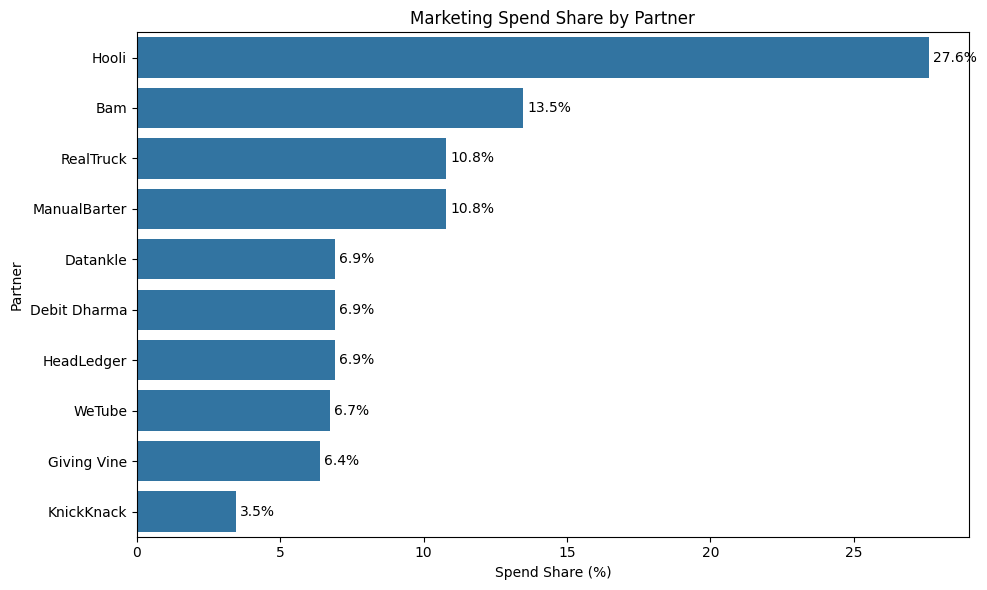

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sorting by spend percentage
spend_sorted = spend_by_partner.sort_values("spend_pct", ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=spend_sorted,
    x="spend_pct",
    y="partner"
)

#percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)

plt.title("Marketing Spend Share by Partner")
plt.xlabel("Spend Share (%)")
plt.ylabel("Partner")

plt.tight_layout()
plt.show()


###Currently we are spending only 6.9% and 6.4% on Debit Dharma and Giving Vine respectfully, despite demonstrating strong acquisition efficiency.
###These partners are strong candidates for an incremental budget prioritization

In [115]:
ad_channels.head(16)

,channel_id,channel_name,category,partner,campaign,campaign_key
0,1,Search Engine-Hooli_Convertible,Search Engine,Hooli,Convertible,Search Engine - Hooli_Convertible
1,2,Search Engine-Hooli_Sedan,Search Engine,Hooli,Sedan,Search Engine - Hooli_Sedan
2,3,Search Engine-Hooli_Truck,Search Engine,Hooli,Truck,Search Engine - Hooli_Truck
3,4,Search Engine-Bam_Convertible,Search Engine,Bam,Convertible,Search Engine - Bam_Convertible
4,5,Search Engine-Bam_Sedan,Search Engine,Bam,Sedan,Search Engine - Bam_Sedan
5,6,Search Engine-Bam_Truck,Search Engine,Bam,Truck,Search Engine - Bam_Truck
6,7,Online Video-Datankle_Teen,Online Video,Datankle,Teen,Online Video - Datankle_Teen
7,8,Online Video-Datankle_25+,Online Video,Datankle,25+,Online Video - Datankle_25+
8,9,Online Video-WeTube_Teen,Online Video,WeTube,Teen,Online Video - WeTube_Teen
9,10,Online Video-WeTube_25+,Online Video,WeTube,25+,Online Video - WeTube_25+


###Hooli operates across three categories,covering body styles of convertibles,sedan and trucks, its important to retrospect here by asking a question
###Despite with a healthy cac,are we getting strong sales numbers from this partner "Hooli" ?
###If hooli delivered high sales numbers along with efficient cac, we can focus at maintaining the same 27% of campaign spend.A cautious increment by 10-15% could be justified, to avoid diminishing returns while prioritizing more efficient but underfunded partners

###More Importantly, its also important to understand the clicks coming from them are of good quality, how effective they are to convert into a lock and final sale?.

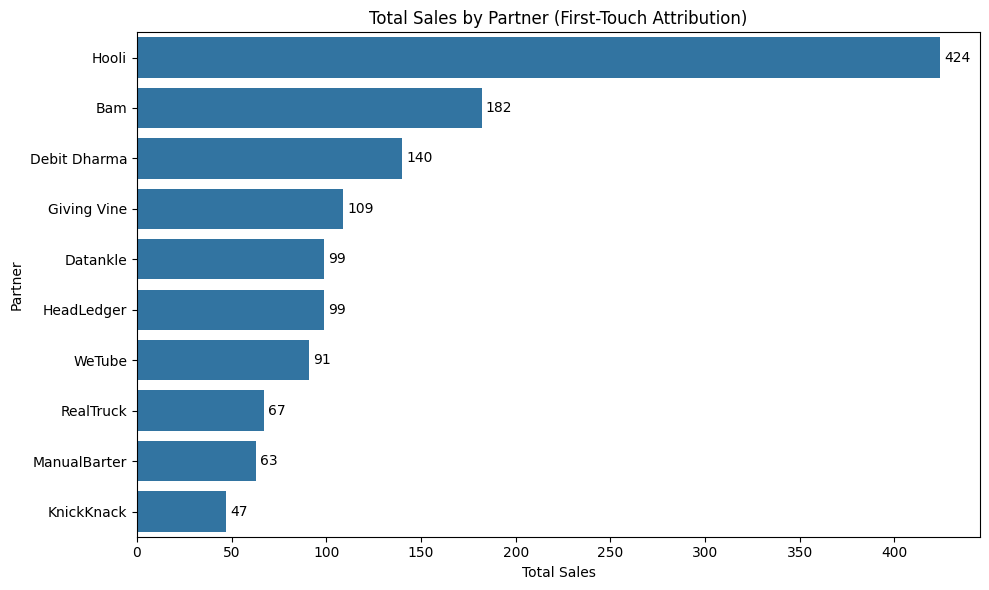

In [116]:

# Sort data
sales_sorted = sales_by_partner.sort_values("total_sales", ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=sales_sorted,
    x="total_sales",
    y="partner"
)

# Add value labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.title("Total Sales by Partner (First-Touch Attribution)")
plt.xlabel("Total Sales")
plt.ylabel("Partner")

plt.tight_layout()
plt.show()


###Hooli currently delivering the most sale numbers ,its important to retain the marketing budget or may be increase by 10-20% can be considered after also accounting for any sort of seasonal factors. Its also important to continously monitor whether this incremental spend continues to generate healthy returns

###Bam sits in a reasonale sweet spot with a 212 cac, but with a solid 182 sales.

###Its also important to focus on underperforming partners as well
###Real truck and ManualBarter considered to be least on number of sales,only delivered 67 and 63 sales respectively despite allocating 20% of total marketing spend

###A Special mention to Giving Vine, especially from finance partnership category, delivering best roi ,also it stood at 4th place interms of sales numbers, 2nd interms of cac. which means we can definitely do a controlled rellocation of money spent from real truck and manual barter to Giving vine and bam(strong sales numbers)